In [13]:
# Project 2: Data Classification Using AI
# DecodeLabs AI Internship - Batch 2026

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              f1_score, accuracy_score)

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [15]:
# Load the Iris Dataset (built-in, no download needed!)
iris = load_iris()

# Convert to DataFrame for easy viewing
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({
    0: 'Setosa', 
    1: 'Versicolor', 
    2: 'Virginica'
})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass Distribution:")
print(df['species_name'].value_counts())

Dataset Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

Class Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [17]:
# Separate features and target
X = iris.data   # 4 features: sepal length, sepal width, petal length, petal width
y = iris.target # 3 classes: Setosa, Versicolor, Virginica

# PHASE 1: Feature Scaling using StandardScaler
# Raw data is biased → Standard Scaled is balanced (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before Scaling (first row):", X[0])
print("After Scaling  (first row):", X_scaled[0].round(3))
print("\nScaling done! ✅")

Before Scaling (first row): [5.1 3.5 1.4 0.2]
After Scaling  (first row): [-0.901  1.019 -1.34  -1.315]

Scaling done! ✅


In [19]:
# PHASE 2: Split data — 80% training, 20% testing
# Shuffle=True removes order bias
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    shuffle=True        # randomize before splitting
)

print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)} (80%)")
print(f"Testing samples  : {len(X_test)}  (20%)")
print("\nSplit done! ✅")

Total samples    : 150
Training samples : 120 (80%)
Testing samples  : 30  (20%)

Split done! ✅


In [21]:
# PHASE 3: Apply KNN Algorithm
# K=5 means look at 5 nearest neighbors and take majority vote

model = KNeighborsClassifier(n_neighbors=5)

# FIT — Memorize the training data
model.fit(X_train, y_train)

# PREDICT — Apply logic on test data
predictions = model.predict(X_test)

print("Model trained successfully! ✅")
print("\nSample Predictions vs Actual:")
class_names = ['Setosa', 'Versicolor', 'Virginica']
for i in range(5):
    print(f"Predicted: {class_names[predictions[i]]} | Actual: {class_names[y_test[i]]}")

Model trained successfully! ✅

Sample Predictions vs Actual:
Predicted: Versicolor | Actual: Versicolor
Predicted: Setosa | Actual: Setosa
Predicted: Virginica | Actual: Virginica
Predicted: Versicolor | Actual: Versicolor
Predicted: Versicolor | Actual: Versicolor


In [23]:
# PHASE 4: Output Validation

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy : {accuracy * 100:.2f}%")

# F1 Score (more reliable than accuracy)
f1 = f1_score(y_test, predictions, average='weighted')
print(f"F1 Score : {f1:.4f}")

# Full Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions, 
                            target_names=['Setosa', 'Versicolor', 'Virginica']))

Accuracy : 100.00%
F1 Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



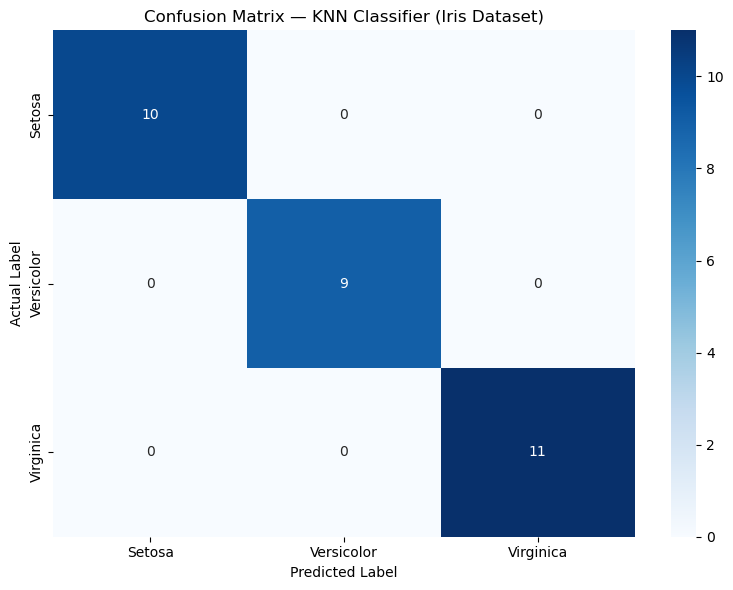

Confusion Matrix saved! ✅


In [25]:
# Confusion Matrix — The Diagnostic Tool
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix — KNN Classifier (Iris Dataset)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion Matrix saved! ✅")

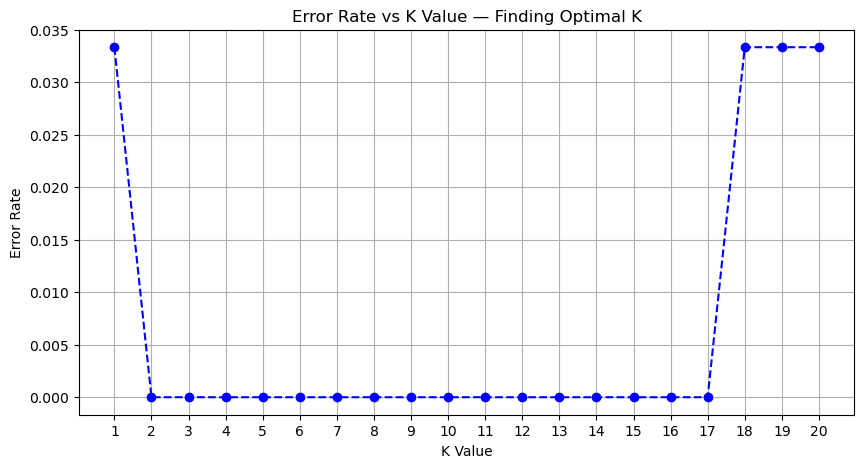

Best K value: 2


In [27]:
# Finding the best K value (The Elbow Method from your PDF)
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), error_rates, 
         marker='o', color='blue', linestyle='--')
plt.title('Error Rate vs K Value — Finding Optimal K')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 21))
plt.grid(True)
plt.savefig('optimal_k.png')
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"Best K value: {best_k}")